# **REVERSE IMAGE SEARCH CONSTRUCTOR - DATA LOAD & REVIEW**

## IMPORTS

In [ ]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import os
import shutil
from zipfile import ZipFile
import tarfile
import requests

## UTILITIES

In [8]:
extensions = ['.jpg', '.JPG', '.jpeg', '.JPEG', '.png', '.PNG']


def get_file_paths(dataset_path):
    file_list = []
    for root, directories, filenames in os.walk(dataset_path):
        for filename in filenames:
            if any(ext in filename for ext in extensions):
                filepath = os.path.join(root, filename)
                if os.path.exists(filepath):
                  file_list.append(filepath)
                else:
                  print(filepath)
    return file_list

## DATA DOWNLOAD

In [26]:
project_root = os.path.dirname(os.getcwd())
base_dir = os.path.join(project_root, "data", "caltech101")
os.makedirs(base_dir, exist_ok=True)

zip_path = os.path.join(base_dir, "caltech-101.zip")
extract_dir = os.path.join(base_dir, "caltech-101")

In [27]:
url = "https://data.caltech.edu/records/mzrjq-6wc02/files/caltech-101.zip?download=1"

print("Downloading dataset...")

response = requests.get(url, stream=True)
with open(zip_path, 'wb') as f:
    shutil.copyfileobj(response.raw, f)

In [28]:
print("Unzipping dataset...")

with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(base_dir)

Unzipping dataset...


In [29]:
tar_path = os.path.join(extract_dir, "101_ObjectCategories.tar.gz")

if os.path.exists(tar_path):
    print("Extracting .tar.gz file...")
    with tarfile.open(tar_path, 'r:gz') as tar_ref:
        tar_ref.extractall(path=extract_dir)
else:
    print(f"{tar_path} not found!")

Extracting .tar.gz file...


In [30]:
print("Cleaning up...")
dirs_to_remove = [
    os.path.join(extract_dir, "101_ObjectCategories", "BACKGROUND_Google"),
    os.path.join(base_dir, "__MACOSX"),
    zip_path,
]

for path in dirs_to_remove:
    if os.path.isdir(path):
        shutil.rmtree(path)
    elif os.path.isfile(path):
        os.remove(path)

Cleaning up...


In [31]:
tar_path = os.path.join(extract_dir, "101_ObjectCategories.tar.gz")

if os.path.exists(tar_path):
    os.remove(tar_path)
    print(f"Deleted {tar_path}")
else:
    print(f"{tar_path} does not exist")


Deleted d:\Data Science\My Projects\Reverse Image Search Engine\data\caltech101\caltech-101\101_ObjectCategories.tar.gz


## DATA REVIEW

In [34]:
dataset_path = os.path.join(base_dir, "caltech-101", "101_ObjectCategories")

filenames = sorted(get_file_paths(dataset_path))
print(f'There are {len(filenames)} files in the dataset.\n')

classes = []
for d in os.listdir(dataset_path):
    if os.path.isdir(os.path.join(dataset_path, d)):
        classes.append(d)

class_counts = []
for cls in classes:
    class_dir = os.path.join(dataset_path, cls)
    files = os.listdir(class_dir)
    count = 0
    for f in files:
        if os.path.isfile(os.path.join(class_dir, f)):
            count += 1
    class_counts.append((cls, count))

class_counts.sort(key=lambda x: x[1], reverse=True)

print("Top 10 classes by number of images:")
for i in range(10):
    cls, count = class_counts[i]
    print(f"{cls:<25} - {count:>5}")

There are 8677 files in the dataset.

Top 10 classes by number of images:
airplanes                 -   800
Motorbikes                -   798
Faces                     -   435
Faces_easy                -   435
watch                     -   239
Leopards                  -   200
bonsai                    -   128
car_side                  -   123
ketch                     -   114
chandelier                -   107


Displaying 5 random images from top 3 classes:


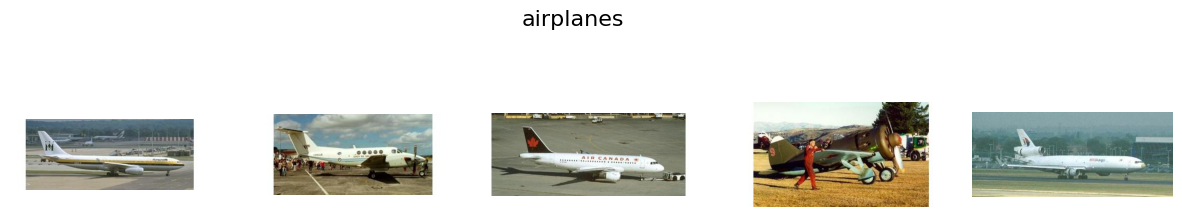

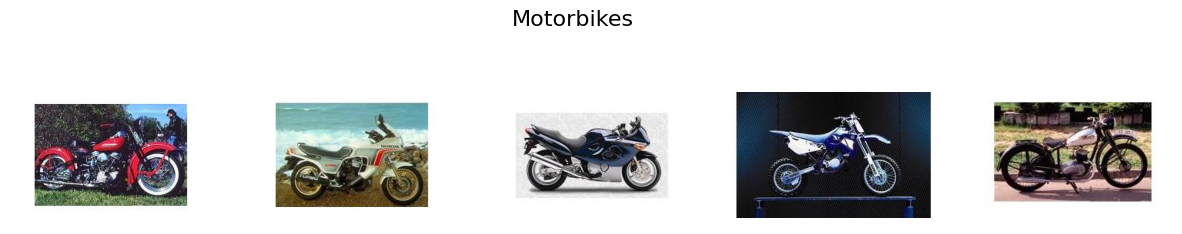

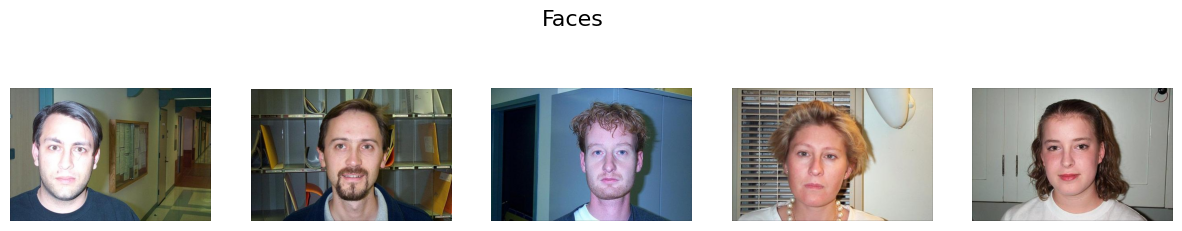

In [35]:
print("Displaying 5 random images from top 3 classes:")

for i in range(3):
    cls, count = class_counts[i]
    class_dir = os.path.join(dataset_path, cls)
    images = []
    for f in os.listdir(class_dir):
        if os.path.isfile(os.path.join(class_dir, f)):
            images.append(f)
    random_images = random.sample(images, min(5, len(images)))

    plt.figure(figsize=(15,3))
    plt.suptitle(cls, fontsize=16)
    for j, img_name in enumerate(random_images):
        img_path = os.path.join(class_dir, img_name)
        img = mpimg.imread(img_path)
        plt.subplot(1, 5, j+1)
        plt.imshow(img)
        plt.axis('off')
    plt.show()

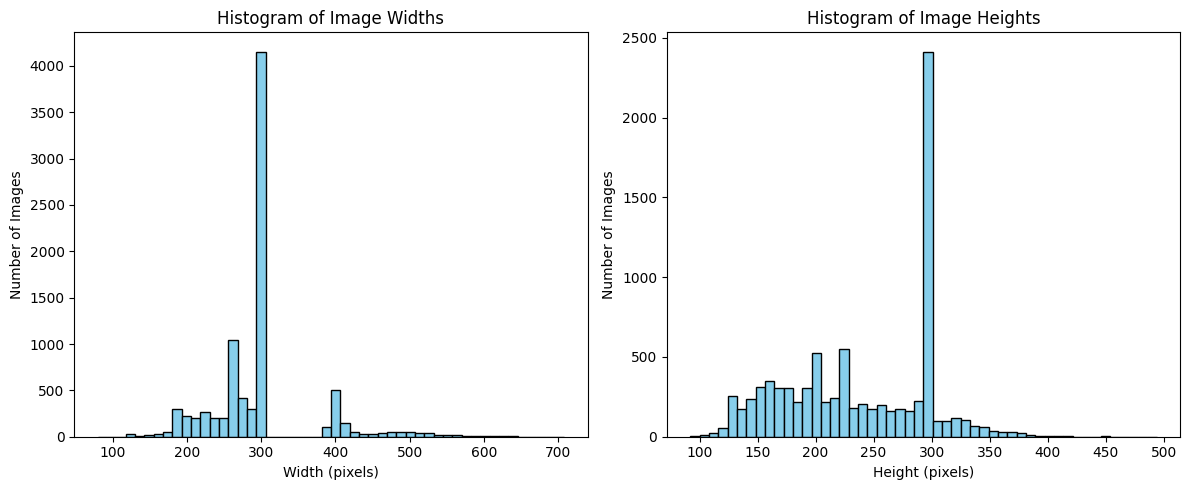

In [36]:
widths = []
heights = []

for cls in classes:
    class_dir = os.path.join(dataset_path, cls)
    for filename in os.listdir(class_dir):
        filepath = os.path.join(class_dir, filename)
        if os.path.isfile(filepath):
            try:
                img = Image.open(filepath)
                w, h = img.size
                widths.append(w)
                heights.append(h)
            except:
                pass

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(widths, bins=50, color='skyblue', edgecolor='black')
plt.title('Histogram of Image Widths')
plt.xlabel('Width (pixels)')
plt.ylabel('Number of Images')

plt.subplot(1,2,2)
plt.hist(heights, bins=50, color='skyblue', edgecolor='black')
plt.title('Histogram of Image Heights')
plt.xlabel('Height (pixels)')
plt.ylabel('Number of Images')

plt.tight_layout()
plt.show()